In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor

from bptf import BPTF as BPTF
import bptf

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Generate data

In [3]:
rn.seed(0)

data = generate(shp=(200, 200, 20, 12, 3), K=10)[1]
data = sparse.COO(data)

# Fit with BPTF

In [4]:
n_components = 50
max_iter = 100
mask = None
device = 'cuda'
tol = 1e-10

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

100%|██████████| 100/100 [19:21<00:00, 11.61s/it]


BPTF(data_shape=(200, 200, 20, 12, 3), n_components=50)

# Fit with own BPTF_torch

In [5]:
from own_implementation import BPTF as BPTF_torch

ELBO = 503597473.30138344, change = 8.662207510916668e-08, time taken = 1.5254271030426025: 100%|██████████| 100/100 [02:30<00:00,  1.50s/it]


Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-1218898953.5771945, 466989737.8856667, 491490352.56718004, 501722837.24188006, 503172973.09545034, 503436619.8932133, 503515051.8429106, 503544028.7645717, 503551450.25175935, 503553844.0359731, 503554795.5206941, 503555298.6466034, 503555659.16733503, 503555952.2713848, 503556210.71522135, 503556445.37720597, 503556664.1277674, 503556872.3716426, 503557072.2636473, 503557269.5913378, 503557460.1231611, 503557643.58339304, 503557819.659557, 503557992.29115075, 503558163.6795564, 503558337.67607313, 503558515.9441418, 503558700.67182195, 503558900.3258655, 503559119.8638055, 503559366.74590725, 503559637.55821943, 503559898.0674971, 503560068.84898293, 503560255.0788479, 503560484.43670005, 503560712.90806067, 503561065.1250215, 503562030.3482074, 503564904.1705153, 503568023.6683092, 503569546.8525138, 503576928.32213974, 503583753.3399471, 503591107.3668825, 503593753.7841943, 503594319.48

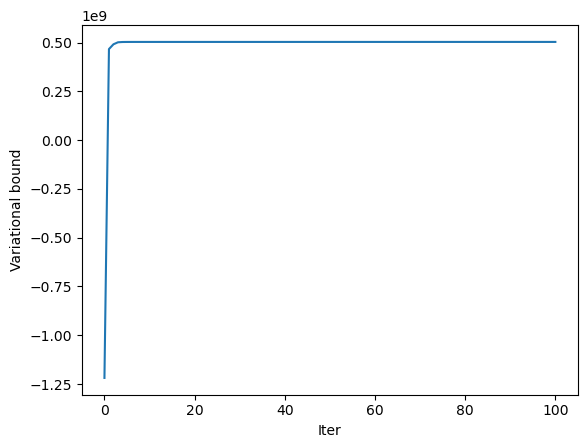

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 12, 3]), device='cuda',
     n_components=50)

In [6]:
data = torch.tensor(data.todense(), dtype = torch.float64, device=device)
BPTF_model_torch = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model_torch.fit(data, mask = None, max_iter = max_iter, verbose=True, tol=tol)

# Check similarity

In [10]:
BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model.G_DK_M]
fro_norm_rel_diff = torch.norm(BPTF_model_torch.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro') / torch.norm(tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro')
print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

threshold = 0.05
diff = torch.abs(BPTF_model_torch.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
prop_exceed = (diff > threshold).sum().item() / diff.numel()
print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

Frobenius norm relative difference: 0.004441927492507868
Proportion of elements with difference greater than 0.05 = 0.017452881944444443


tensor(0.8156, device='cuda:0') tensor(0.1377, device='cuda:0') tensor(588.5577, device='cuda:0')
tensor([ 30742,   4305,   9798,   8854,  72032,  30215, 156165,   3587,  34773,
         83839,  56321,  12012], device='cuda:0')


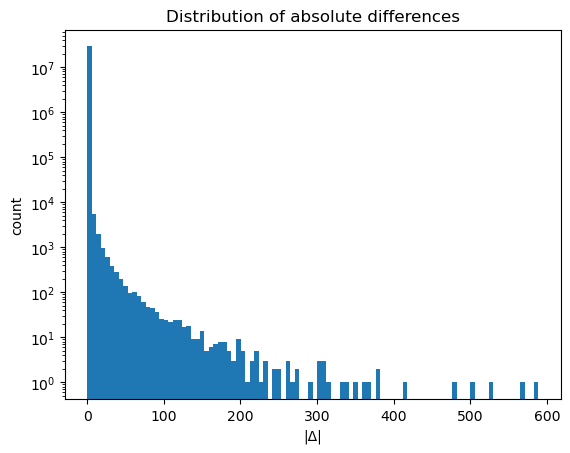

In [ ]:
# 1) How big are the large errors?
big = diff[diff > 0.05]
print(big.mean(), big.median(), big.max())

# 2) Histogram of the absolute differences
import matplotlib.pyplot as plt
plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')

# 3) Where do they occur?  Example for mode-4 time slices
exceed_mask = (diff > 0.05)
time_exceed = exceed_mask.view(200, 200, 20, 12, 3).sum(dim=(0,1,2,4))
print(time_exceed)  # counts per month